Bi-LSTM for Gold price prediction

In [1]:
#!pip install tensorflow
# Install required libs
#!pip install yfinance pandas numpy scikit-learn 

In [2]:
import pandas as pd, numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# 1. Download data (2000–2026)
gold = yf.download("GC=F", start="2000-01-01")
dxy  = yf.download("DX-Y.NYB", start="2000-01-01")
vix  = yf.download("^VIX", start="2000-01-01")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
# 2. Merge datasets
df = pd.DataFrame()
df['Close'] = gold['Close']
df['Return'] = df['Close'].pct_change()
df['Volume'] = gold['Volume']
df['DXY'] = dxy['Close']
df['VIX'] = vix['Close']

# Add dummy OI & Sentiment (replace with real later)
df['OI'] = df['Volume'].rolling(5).mean()
df['Sentiment'] = np.random.normal(0, 0.1, len(df))


df = df.dropna()


In [5]:
# 3. Scaling
features = ['Return','Volume','OI','DXY','VIX','Sentiment']
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])


In [6]:
# 4. Sequence creation
def create_seq(data, seq_len=120):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len,0])
    return np.array(X), np.array(y)

X, y = create_seq(scaled)

# 5. Train-test split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [7]:
# Input (batch, timesteps, features)
inp = layers.Input(shape=(120, X.shape[2]))

# Transformer Encoder (Attention)
attn = layers.MultiHeadAttention(
    num_heads=4, key_dim=32, dropout=0.1
)(inp, inp)

x = layers.LayerNormalization()(inp + attn)

# BiLSTM (temporal learning)
x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True, dropout=0.2)
)(x)

# Attention Pooling (safe)
score = layers.Dense(1)(x)
weights = layers.Softmax(axis=1)(score)
context = layers.Multiply()([x, weights])

# Replace Lambda / tf.reduce_sum
context = layers.GlobalAveragePooling1D()(context)

#  Dense Head
x = layers.Dense(64, activation='relu')(context)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)

# Output
output = layers.Dense(1)(x)

# Model
model = Model(inputs=inp, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 120, 6)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 120, 6)            │           3,462 │ input_layer[0][0],         │
│ (MultiHeadAttention)          │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 120, 6)            │               0 │ input_layer[0][0],         │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 120, 6)            │              12 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 120, 128)          │          36,352 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 120, 1)            │             129 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ softmax_1 (Softmax)           │ (None, 120, 1)            │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 120, 128)          │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ softmax_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 128)               │               0 │ multiply[0][0]             │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 50,324 (196.58 KB)

 Trainable params: 50,324 (196.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 0.0440 - mae: 0.1342 - val_loss: 0.0031 - val_mae: 0.0376
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0048 - mae: 0.0530 - val_loss: 0.0031 - val_mae: 0.0379
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 0.0044 - mae: 0.0502 - val_loss: 0.0032 - val_mae: 0.0380
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0042 - mae: 0.0488 - val_loss: 0.0031 - val_mae: 0.0379
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 0.0039 - mae: 0.0468 - val_loss: 0.0032 - val_mae: 0.0389
Epoch 6/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0037 - mae: 0.0447 - val_loss: 0.0032 - val_mae: 0.0400
Epoch 7/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0033 - mae: 0.0421 - val_loss: 0.0031 - val_mae: 0.0376
Epoch 8/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0033 - mae: 0.0418 - val_loss: 0.0032 - val_mae: 0.0385
Epoch 9/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 

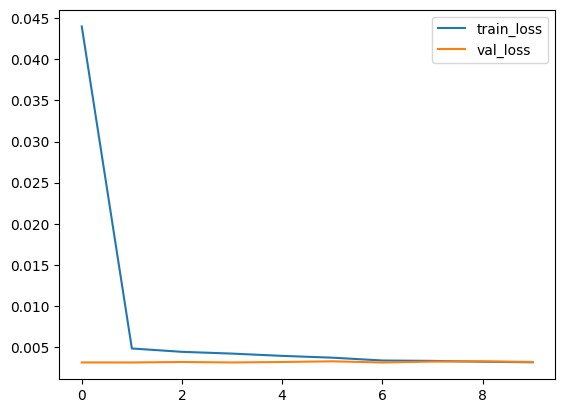

In [8]:
# 7.Train performance
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)


plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [9]:
#8.Test performance
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0032 - mae: 0.0400
Test Loss (MSE): 0.003199239494279027
Test MAE: 0.03995142877101898


In [10]:
#9. Predict
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score:", r2_score(y_test, pred))

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
RMSE: 0.05656181900262396
R2 Score: -0.03039503669625243


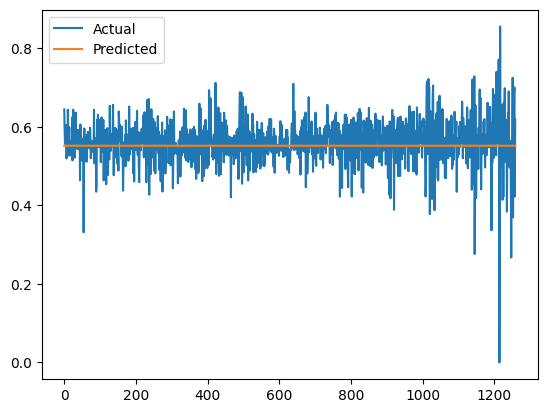

In [11]:
#Gold prediction vs actual
plt.plot(y_test, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

The above code is the starting point of the project: to predict gold price using deep learning methods. We will gradually 